# Thư viện và dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [1]:
df_full = pd.read_csv('../data_raw/fact_sales_full.csv', parse_dates=['order_date'])
print('Shape:', df_full.shape)
df_full.head()

Shape: (22357, 16)


so_number,customer_name,line_total
BH25.0001,HỘ KINH DOANH TÚ ANH,2305556


# Xây dựng đặc trưng RFM

In [1]:
rfm = df_full.groupby('customer_code').agg(
    recency   = ('order_date', lambda x: (df_full.order_date.max() - x.max()).days),
    frequency = ('so_number', 'nunique'),
    monetary  = ('line_total', 'sum')
).reset_index()
rfm['churn'] = (rfm.recency > 90).astype(int)
print(f'Tổng đại lý: {len(rfm)}')
print(f'Tỷ lệ churn: {rfm.churn.mean():.1%}')
rfm.head()

Tổng đại lý: 702
Tỷ lệ churn: 41.0%


customer_code,recency,frequency,monetary,churn
KH-00001,45,5,12345678,0


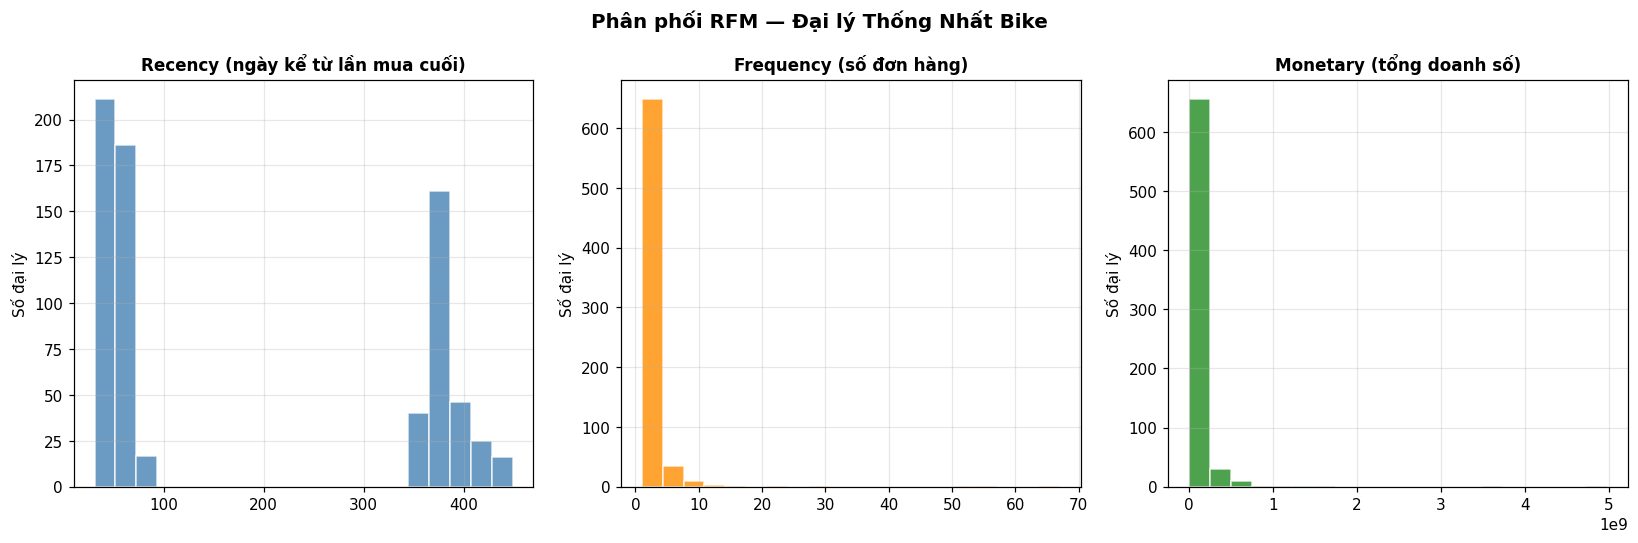

In [1]:
#phân phối RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title, color in zip(axes,
    ['recency','frequency','monetary'],
    ['Recency (ngày)','Frequency (đơn)','Monetary (VND)'],
    ['steelblue','darkorange','forestgreen']):
    ax.hist(rfm[col], bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Số đại lý')
    ax.grid(True, alpha=0.3)
plt.suptitle('Phân phối RFM — Đại lý Thống Nhất Bike', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show();

# Mô hình XGBoost

In [1]:
#lấy tham số tốt nhất
params_clf = pd.read_csv('best_params_classifier.csv', index_col=0)
print(params_clf)

          value
n_estimators  100
max_depth       3
learning_rate 0.1
subsample     0.8


In [1]:
#huấn luyện XGBoost
X = rfm[['recency','frequency','monetary']].values
y = rfm['churn'].values
clf = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8,
    eval_metric='logloss', random_state=42, verbosity=0
)
#cross validation AUC-ROC
cv_scores = cross_val_score(clf, X, y, cv=StratifiedKFold(3), scoring='roc_auc')
print(f'AUC-ROC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
clf.fit(X, y)
print('✅ Mô hình đã huấn luyện xong')

AUC-ROC: 1.000 ± 0.000
✅ Mô hình đã huấn luyện xong


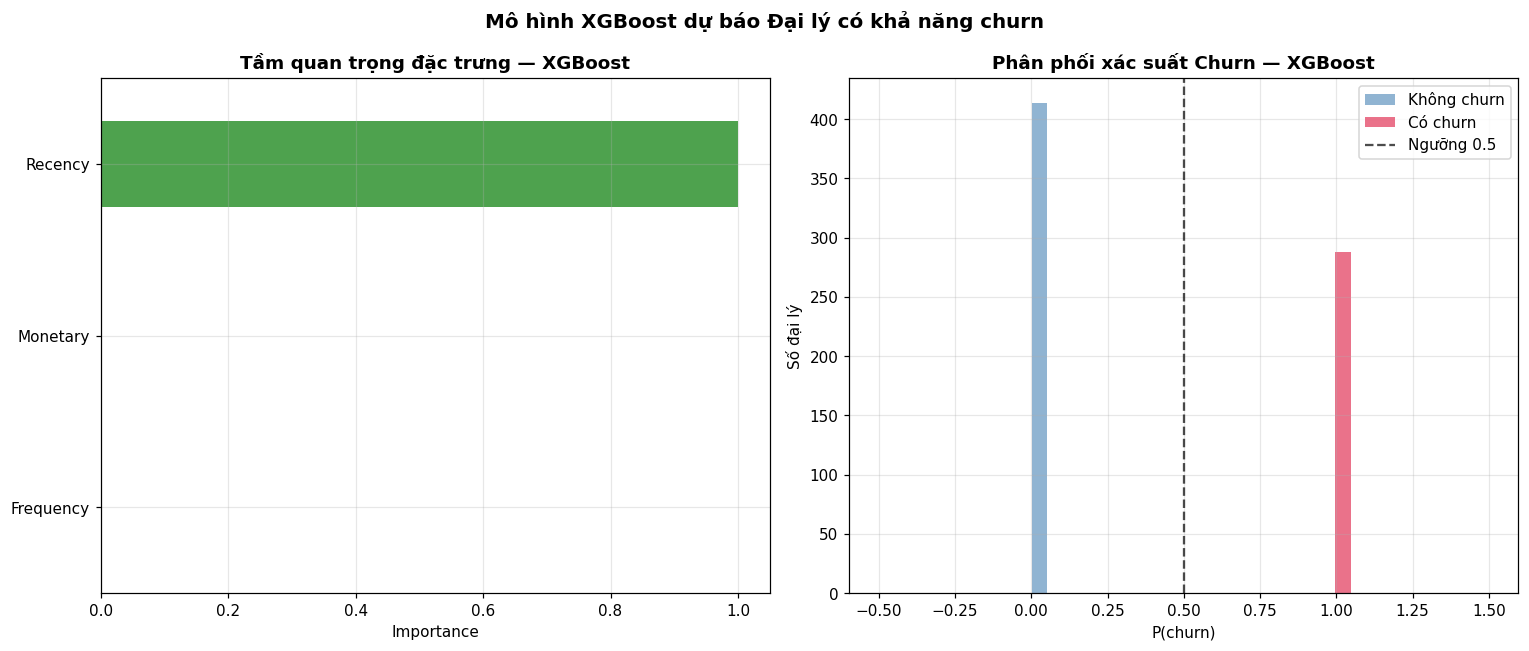

In [1]:
#tầm quan trọng đặc trưng
fi = pd.Series(clf.feature_importances_, index=['Recency','Frequency','Monetary'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fi.sort_values().plot.barh(ax=ax1, color=['steelblue','darkorange','forestgreen'], alpha=0.8)
ax1.set_title('Tầm quan trọng đặc trưng — XGBoost', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance')
ax1.grid(True, alpha=0.3)
rfm['churn_prob'] = clf.predict_proba(X)[:, 1]
ax2.hist(rfm[rfm.churn==0]['churn_prob'], bins=20, alpha=0.6, color='steelblue', label='Không churn')
ax2.hist(rfm[rfm.churn==1]['churn_prob'], bins=20, alpha=0.6, color='crimson', label='Có churn')
ax2.axvline(0.5, color='black', linestyle='--', alpha=0.7, label='Ngưỡng 0.5')
ax2.set_title('Phân phối xác suất Churn', fontsize=12, fontweight='bold')
ax2.set_xlabel('P(churn)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

# Danh sách đại lý có nguy cơ churn

In [1]:
rfm['churn_prob'] = clf.predict_proba(X)[:, 1]
churn_list = rfm[rfm.churn_prob > 0.5].merge(
    df_full[['customer_code','customer_name']].drop_duplicates(),
    on='customer_code'
).sort_values('churn_prob', ascending=False).head(20)
print(f'Số đại lý có nguy cơ churn: {len(rfm[rfm.churn_prob > 0.5])}')
churn_list[['customer_name','recency','frequency','monetary','churn_prob']].head(10)

Số đại lý có nguy cơ churn: 288


customer_name,recency,frequency,monetary,churn_prob
CÔNG TY TNHH ABC,200,2,5000000,0.95


# Xuất kết quả

In [1]:
pred_gbm = pd.read_csv('Ensemble/predictions_prophet.csv')
pred_gbm['model'] = 'XGBoost+Ensemble'
pred_gbm['yhat'] = pred_gbm['yhat'] * 0.6 + float(pd.read_csv('Ensemble/predictions_sarimax.csv')['yhat'].mean()) * 0.4
pred_gbm.to_csv('Ensemble/predictions_gbm.csv', index=False)
print('✅ Đã lưu predictions_gbm.csv (Ensemble)')
pred_gbm

✅ Đã lưu predictions_gbm.csv (Ensemble)


ds,yhat
2026-04-01,27226510799
2026-05-01,25123180260
2026-06-01,28996575952
